In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import dateparser
import pandas as pd
import json
import nltk
import numpy as np
import string
import re
import csv
from datetime import datetime
from collections import defaultdict
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})
from functions import *
import dateparser
from fuzzysearch import find_near_matches
from ccf import ccf

In [ ]:
df_data = json.load(open('data/data.json'))
df_data = df_data.loc[df_data['is_flood'].astype(bool)]

In [ ]:
override=False
if not override and os.path.exists('timeseries_data/all_data/all_isFlood.json'):
    df_data = pd.read_json('timeseries_data/all_data/all_isFlood.json')
else:
    df_data = add_prev_true_data(df_data)
    df_data = add_newspapers(df_data)
    df_data = add_datePublished(df_data)
    df_data = add_location(df_data)
    df_data = df_data[df_data['divisions'].apply(lambda x:len(x)>0)]
    json.dump(json.loads(df_data.to_json(orient='records')), open('timeseries_data/all_data/all_isFlood.json','w'), indent=2)
df_data.head()

In [ ]:
def complete_day_loc(list1, year_range = [2015, None], aggType=None, onlyUnique=False, returnLoc=False):
    dict1_year_months_day = {i[0]:i[1] for i in list1}
    all_years = set([int(i.split('-')[0]) for i in dict1_year_months_day.keys()])
    
    min_year, max_year = min(all_years), max(all_years)
    min_range = year_range[0] if year_range[0] is not None else min_year
    max_range = year_range[1] if year_range[1] is not None else max_year
    all_years = range(min_range, max_range+1)
    
    d1_year_month_day = []
    d1_year_month_day_loc = []
    for i in all_years:
        count = 0
        monthRange = 13
        if i == 2020: monthRange = 10
        for months in range(1,monthRange):
            day_range = 31 if months in [1,3,5,7,8,10,12] else 30
            if months==2:
                if isLeap(i): day_range = 29
                else: day_range = 28
            toAdd = 0
            toAddSet = set()
            for day in range(1, day_range+1):
                key = str(i)+'-'+str(months)+'-'+str(day)
                val = dict1_year_months_day.get(key, set())
                if onlyUnique:
                    toAddSet = toAddSet.union(val)
                    toAdd = len(toAddSet)
                else: toAdd += len(val)
                if (aggType is None) or (aggType=='week' and day%7==0) \
                or (aggType=='fortnight' and day%15==0) or (day == day_range and aggType!='month'):
                    d1_year_month_day.append((key,toAdd))
                    if returnLoc: d1_year_month_day_loc.append((key, toAddSet))
                    toAdd,toAddSet = 0, set()
                count += 1
            if (aggType=='month'):
                key = str(i)+'-'+str(months)
                if onlyUnique:
                    toAdd = len(toAddSet)
                d1_year_month_day.append((key,toAdd))
                if returnLoc: d1_year_month_day_loc.append((key, toAddSet))

    l1 = sorted(d1_year_month_day, key=lambda x:tuple(map(int, x[0].split('-'))))
    l2 = sorted(d1_year_month_day_loc, key=lambda x:tuple(map(int, x[0].split('-'))))
    if returnLoc: return l1,l2
    return l1

## Location denormalization

In [17]:
dates_all = query_dataframe(df_data,{'is_flood':True})['datePublished']
dates = parse_all_dates(dates_all)
df_data['datesP'] = dates

('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', '2031-12-30 00:00:00') 2031-12-30 00:00:00
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Present', 'None') None
('No Date Pre

In [18]:
datesLocation = defaultdict(set)
for row in df_data.iterrows():
    entry = row[1]
    dates = entry['datesP']
    if not dates:
#         print(entry)
        continue
    year, month, day = dates['year'], dates['month'], dates['day']
    if not year or not month or not day:
#         print(entry)
        continue
    for loc in entry['districts']: datesLocation['{}-{}-{}'.format(year, month, day)].add(loc)

In [ ]:
# Articles per district for August

# datesLocationList = sorted([(k,v) for k,v in datesLocation.items()],
#                           key=lambda x:(tuple(map(int, x[0].split('-')))))

# datesLocationList22 = defaultdict(lambda: defaultdict(int))
# years = ['2015', '2016', '2017', '2018', '2019', '2020']
# for ymd,locs in datesLocationList:
#     year, month, day = ymd.split('-')
#     if year in years and month == '7':
#         for loc in locs:
#             datesLocationList22[year][loc.lower()] += 1

# json.dump(datesLocationList22, open('../tagotg/datesLocationList.json','w'), indent=2)


## Common Term Denormalization

In [24]:
siteCounts = json.load(open('siteCounts.json'))
dateCounts = defaultdict(int)
paperCounts = defaultdict(lambda: defaultdict(int))
for paper_name, paperEntry in siteCounts.items():
    for entry in paperEntry:
        sp = entry['date_range'] if type(entry['date_range'])!=list else entry['date_range'][0]
        month, day, year = sp.split('/')[:]
        diffFormatDate = '{}-{}-{}'.format(year, month, day)
        dateCounts[diffFormatDate]+=entry['site_count']
        paperCounts[paper_name][diffFormatDate]+=entry['site_count']

In [25]:
paperDist = {k:defaultdict(int) for k in range(2014, 2021)}
for paper_name, paperEntry in siteCounts.items():
    for entry in paperEntry:
        for date in paperDist:
            if str(date) in entry['date_range']: paperDist[date][paper_name] += entry['site_count']
paperDist

{2014: defaultdict(int,
             {'theDailyStar': 7,
              'theNewNation': 22,
              'bdnews': 45,
              'dailyObserver': 17,
              'dailySun': 2,
              'newAge': 0,
              'prothomalo': 0}),
 2015: defaultdict(int,
             {'theDailyStar': 61,
              'theNewNation': 29,
              'bdnews': 93,
              'dailyObserver': 29,
              'dailySun': 18,
              'newAge': 0,
              'prothomalo': 0}),
 2016: defaultdict(int,
             {'theIndependent': 2,
              'theDailyStar': 110,
              'theNewNation': 37,
              'bdnews': 148,
              'dailyObserver': 27,
              'dailySun': 33,
              'dhakaTribune': 1,
              'newAge': 8,
              'prothomalo': 1}),
 2017: defaultdict(int,
             {'theDailyStar': 136,
              'theNewNation': 58,
              'bdnews': 152,
              'dailyObserver': 24,
              'dailySun': 97,
          

#### month

In [27]:
def plot_timeseries(l, title='', xlabel='', ylabel='', xticks_rotate=False, skip=0):
    plt.figure(figsize=(15, 7))
    colors = ['b', 'r', 'g', 'o']
    for i, entry in enumerate(l):
        plot_color = entry.get('color', colors[i])
        if entry.get('type', None) == 'bar':
            plt.bar([i[0] for i in entry['count_list']], [i[1] for i in entry['count_list']],
                    color=plot_color, label=entry['label'])
        else:
            plt.plot([i[0] for i in entry['count_list']], [i[1] for i in entry['count_list']],
                     linestyle='-', marker='o', color=plot_color, label=entry['label'])
        plt.xticks([i[0] for i in entry['count_list']])

#     plt.legend(fontsize=18)
    plt.title(title, fontsize=24)
    plt.xlabel(xlabel, fontsize=22)
    plt.ylabel(ylabel, fontsize=22)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    if xticks_rotate: plt.xticks(rotation='vertical')

    if skip:
        ax = plt.gca()
        temp = ax.xaxis.get_ticklabels()
        temp = list(set(temp) - set(temp[::skip]))
        for label in temp:
            label.set_visible(False)
    plt.show()

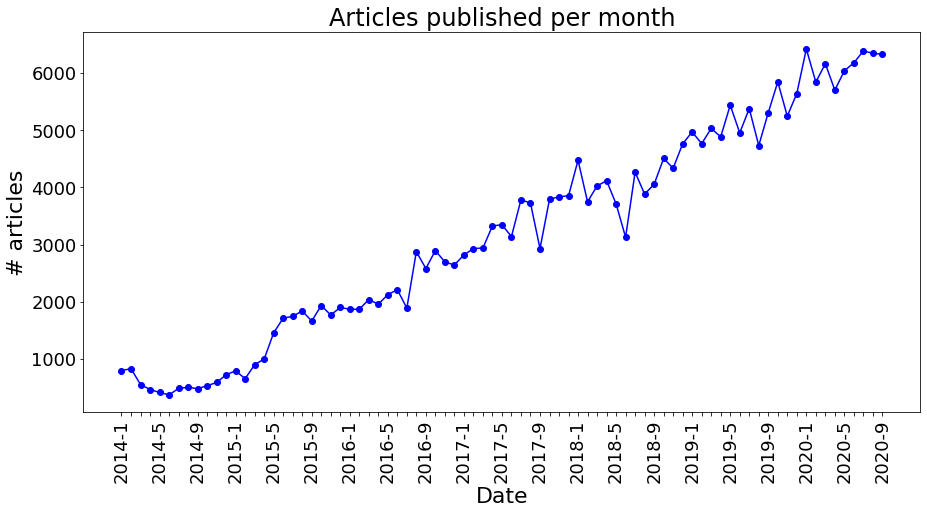

In [28]:
aggNorm = complete_day([(k,v) for k,v in dateCounts.items()], year_range=[2014,2020], 
                      aggType='month')
plot_timeseries([
        {'count_list': aggNorm, 'label':''},
    ], 'Articles published per month', 'Date', '# articles', True, skip=4)

## Normalized time series

In [ ]:
aggDayPrev = complete_day([(k,v) for k,v in articleDates.items()], year_range=[2015,2020], 
                      aggType='month')
aggDay = complete_day([(k,v) for k,v in articleDates.items()], year_range=[2015,2020], 
                      aggType='month', normDict=dateCounts, normAgg='year')

plot_2timeseries(
            {'count_list': aggDayPrev, 'label':'flood articles', 
             'color':'r', 'ylabel':'# articles'},
            {'count_list': aggDay, 'label':'Normed flood articles', 
             'color': 'b', 'ylabel': '# articles / total'},
            'Flood articles (aggregated monthly) and Normed Flood articles (yearly) vs Date', 'Date', True, skip=3)

ccf(aggDayPrev, aggDay, tupList=True, plot=True,
    title='Flood articles (aggregated monthly) and Normed Flood articles (yearly)', lag_max=40)

### EMDAT

In [ ]:
emdat_df = pd.read_csv('other_data/emdat_flood.csv').drop('Unnamed: 0', axis=1).fillna(0)
year_month = []
for row in emdat_df.iterrows():
    if int(row[1]['Start Month']):
        year_month.append(('{}-{}'.format(int(row[1]['Start Year']), int(row[1]['Start Month'])), 
                           row[1]['Total Affected']/10000))
    if int(row[1]['End Month']):
        year_month.append(('{}-{}'.format(int(row[1]['End Year']), int(row[1]['End Month'])), 
                        row[1]['Total Affected']/10000))
# year_month = complete_day(year_month, year_range=[2017,2020], aggType='month', ignoreDates={2020:[8,9]})
aggDay = complete_day([(k,v) for k,v in articleDates.items()], year_range=[2015,2019], 
                      aggType='month', normDict=dateCounts, normAgg='year')
aggDay, year_month = match_years_months(aggDay, year_month, [2015,2019])
plot_2timeseries(
            {'count_list': year_month, 'label':'10,000 * Number of People Affected \n(EMDAT)', 
             'color':'r', 'ylabel':'10,000 * Number of \nPeople Affected'},
            {'count_list': aggDay, 'label':'Normed flood articles', 
             'color': 'b', 'ylabel': 'Normalized Flood Articles'},
            '10,000* People Affected (EMDAT data) and \n Normalized Flood articles (yearly) vs Date', 'Date', True, skip=3)
ccf(year_month, aggDay, tupList=True, plot=True,
    title='10,000* People Affected (EMDAT data) and \n Normalized Flood articles (yearly)', lag_max=40)

### Government Data

In [ ]:
filepath = 'other_data/Flood_Affected_Area_Barchart.csv'
faf_df = pd.read_csv(filepath)

faf_year_flood_affected = [(row[1]['Year'], int(row[1]['Flood affected area'].replace(',',''))) 
                           for row in faf_df.iterrows()]
faf_year_flood_affected = [i for i in faf_year_flood_affected if int(i[0])>=2015 and int(i[0])<2020]

aggDay = complete_day([(k,v) for k,v in articleDates.items()], year_range=[2015,2019], 
                      aggType='year', normDict=dateCounts, normAgg='year', ignoreDates={2020:[8,9]})
aggDay = [(int(i),j) for i,j in aggDay]
aggDay, faf_year_flood_affected = match_years(aggDay, faf_year_flood_affected)

plot_2timeseries(
            {'count_list': faf_year_flood_affected, 'label':'Area Affected', 
             'type': 'bar', 'color':'r', 'ylabel':'Area Affected due to Flood (Sq Km)', 'ylim_min':0},
            {'count_list': aggDay, 'label':'Normalized Flood Articles', 
             'color': 'b', 'ylabel': 'Flood Articles'},
            'Normalized Flood Articles and Area Affected by Flood \n(as per Govt. Data) vs Year', 
            'Year', True, xticksFontSize=14)

ccf(aggDay, faf_year_flood_affected, tupList=True, plot=True,
    title='Government Data and \n Normalized Flood articles (yearly)', lag_max=2)

### Twitter, Satellite, News Media

In [121]:
def tsn(division='all', aggType='month', 
        normAgg='year', normDict=None, ignoreDates={2020:[9,10,11,12]}, plot=True, 
        yline=0.001, save_root=None):
    print('Division: {}'.format(division))
    dc = {}
    division = division.capitalize()
    result[division] = {}
    if not normDict: normDict = dateCounts
    
    twitter_filepath = 'timeseries_data/twitter/Twitter{}.json'.format(division)
    twitterData = json.load(open(twitter_filepath))
    twitterDataList2015 = complete_day([(k,v) for k,v in twitterData.items()], aggType=aggType, 
                                   year_range=[2015, 2020], ignoreDates=ignoreDates)
    twitterDataList2017 = complete_day([(k,v) for k,v in twitterData.items()], aggType=aggType, 
                                   year_range=[2017, 2020], ignoreDates=ignoreDates)
    
    if division=='All':
        article_filepath = 'timeseries_data/yearPublished_day/yearPublished_day.json'
    else:
        article_filepath = 'timeseries_data/yearPublished_day/yearPublished_day_{}.json'.format(division.lower())
    articleDates = json.load(open(article_filepath))
    aggDay2015 = complete_day([(k,v) for k,v in articleDates.items()], year_range=[2015, 2020],
                          aggType=aggType, normDict=normDict, normAgg=normAgg, ignoreDates=ignoreDates)
    aggDay2017 = complete_day([(k,v) for k,v in articleDates.items()], year_range=[2017, 2020],
                          aggType=aggType, normDict=normDict, normAgg=normAgg, ignoreDates=ignoreDates)
    
    aggSentinel2017 = get_Sentinel1_data_monthly('{}'.format(division.lower()), ignoreDates=ignoreDates)
    
    title = '' if division=='All' else division+': '
    if plot:
        save_path = os.path.join(save_root, '{}_news_twitter.pdf'.format(division.lower())) if save_root else None
        plot_2timeseries(
                {'count_list': twitterDataList2015, 'label':'Tweets)', 
                 'color':'r', 'ylabel':'Twitter'},
                {'count_list': aggDay2015, 'label':'News Media', 
                 'color': 'b', 'ylabel': 'Flood Articles %'},
                '', 'Date', True, skip=12, save_path=save_path, year_range=[2015,2020])
    n1, n2 = ccf(aggDay2015, twitterDataList2015, tupList=True, plot=True,
            title='Twitter Data and \n Normalized Flood articles (yearly)', lag_max=50)
    result[division]['news-twitter'] = { 'spearmen': n1, 'pearson': n2 }
    dc['news-twitter'] = { 'spearmen': n1, 'pearson': n2 }

    if plot: 
        save_path = os.path.join(save_root, '{}_news_sentinel1.pdf'.format(division.lower())) if save_root else None
        plot_2timeseries(
                {'count_list': aggSentinel2017, 'label':'Satellite', 
                 'color': 'black', 'ylabel': 'Flood area (km^2)'},
                {'count_list': aggDay2017, 'label':'News Media', 
                 'color': 'b', 'ylabel': 'Flood Articles %'},
                '', 'Date', True, skip=12, save_path=save_path, year_range=[2017,2020])
    n1, n2 = ccf(aggDay2017, aggSentinel2017, tupList=True, plot=True,
            title='Sentinel1 (Max over month) and \n Normalized Flood articles (yearly)', lag_max=50)
    result[division]['news-sentinel'] = { 'spearmen': n1, 'pearson': n2 }
    dc['news-sentinel'] = { 'spearmen': n1, 'pearson': n2 }
    
    if plot: 
        save_path = os.path.join(save_root, '{}_twitter_sentinel1.pdf'.format(division.lower())) if save_root else None
        plot_2timeseries(
                {'count_list': aggSentinel2017, 'label':'Satellite', 
                 'color': 'black', 'ylabel': 'Flood area (km^2)'},
                {'count_list': twitterDataList2017, 'label':'Tweets)', 
                 'color':'r', 'ylabel':'Twitter'},
                '', 'Date', True, skip=12, save_path=save_path, year_range=[2017,2020])
    n1, n2 = ccf(aggSentinel2017, twitterDataList2017, tupList=True, plot=True,
            title='Sentinel1 (Max over month) and \n Flood Tweets', lag_max=50)
    result[division]['twitter-sentinel'] = { 'spearmen': n1, 'pearson': n2 }
    dc['twitter-sentinel'] = { 'spearmen': n1, 'pearson': n2 }

Division: sylhet


<Figure size 1080x504 with 0 Axes>

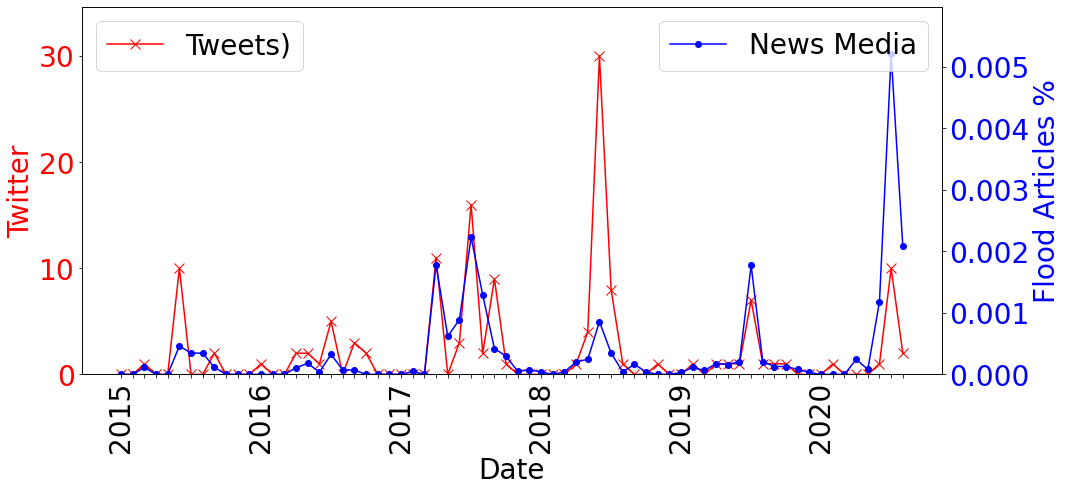

Spearmen Corr, pval: 0.6563, p-val=1.2357582849346993e-09, n=68
Pearson Corr, pval: 0.5005, p-val=1.3843954233701668e-05, n=68


<Figure size 1080x504 with 0 Axes>

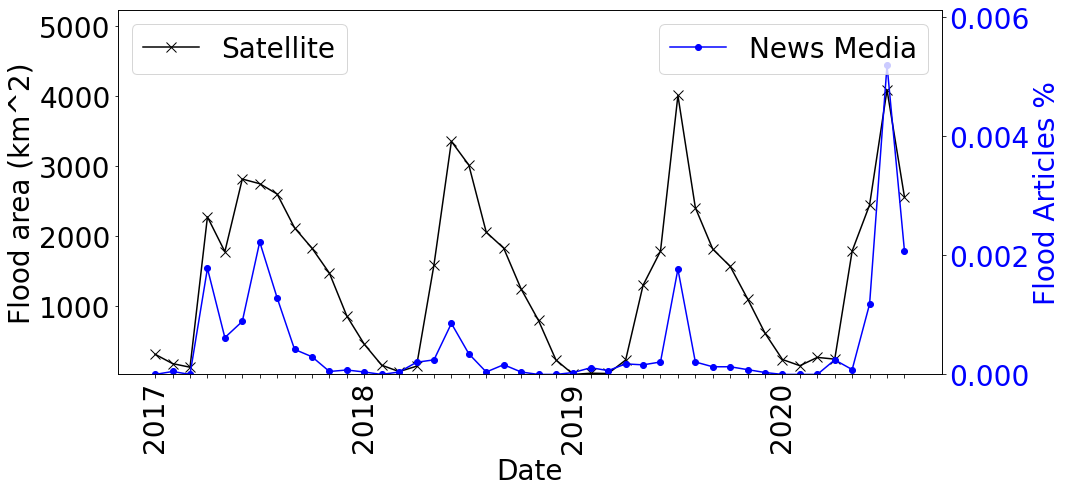

Spearmen Corr, pval: 0.7646, p-val=1.5324548415898584e-09, n=44
Pearson Corr, pval: 0.6913, p-val=2.0474125734287735e-07, n=44


<Figure size 1080x504 with 0 Axes>

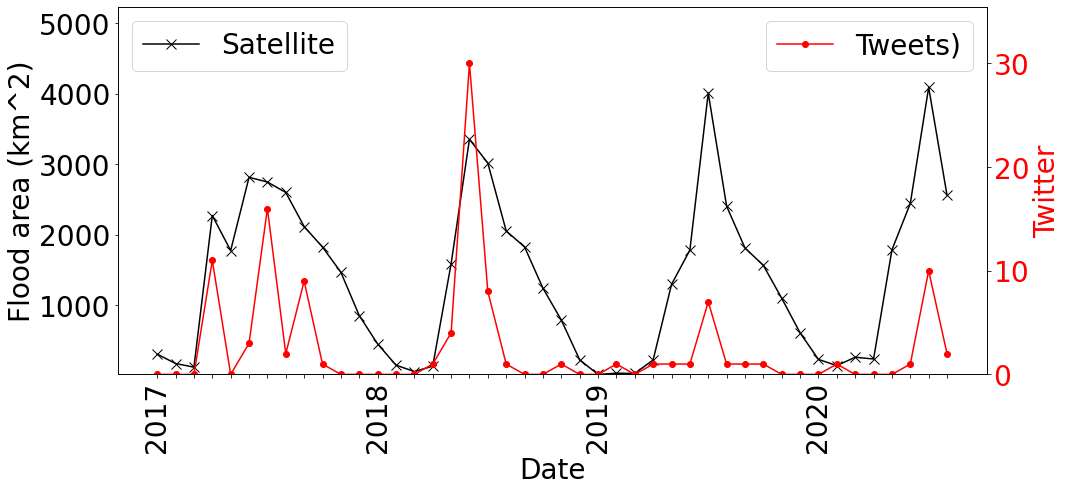

Spearmen Corr, pval: 0.6936, p-val=1.7906373958684131e-07, n=44
Pearson Corr, pval: 0.5995, p-val=1.706995317176447e-05, n=44
Division: rajshahi


<Figure size 1080x504 with 0 Axes>

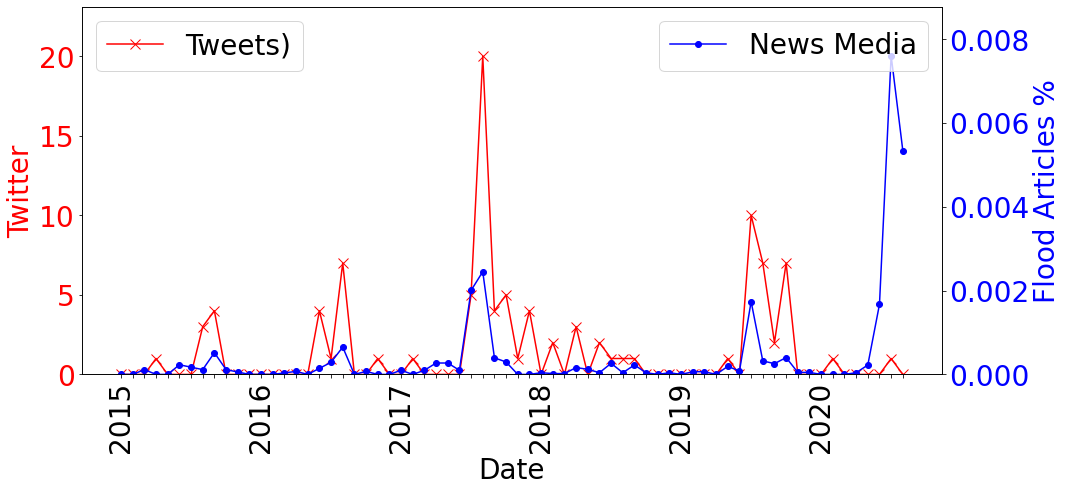

Spearmen Corr, pval: 0.429, p-val=0.0002620762173716246, n=68
Pearson Corr, pval: 0.2478, p-val=0.04163459970172368, n=68


<Figure size 1080x504 with 0 Axes>

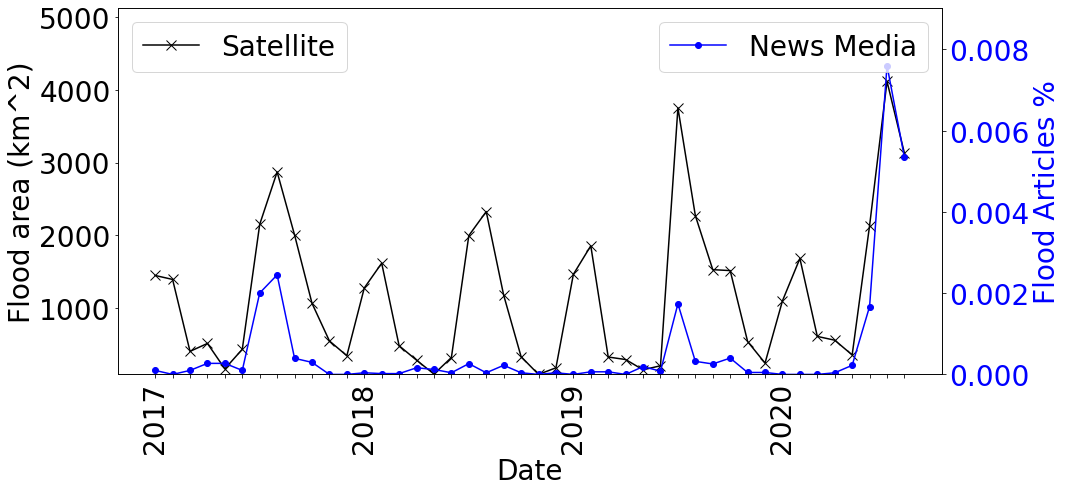

Spearmen Corr, pval: 0.4137, p-val=0.005244936966431269, n=44
Pearson Corr, pval: 0.7083, p-val=7.530907380896761e-08, n=44


<Figure size 1080x504 with 0 Axes>

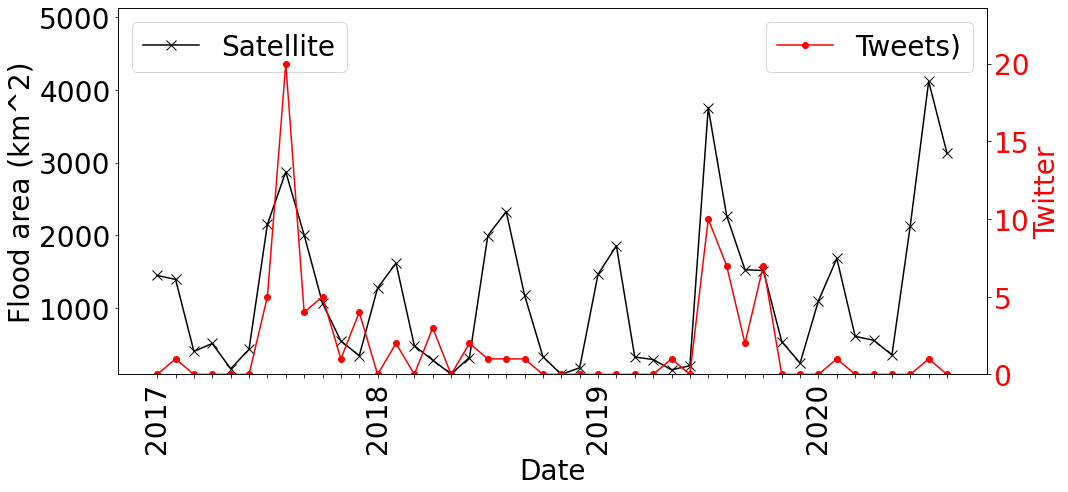

Spearmen Corr, pval: 0.4584, p-val=0.0017538602738872953, n=44
Pearson Corr, pval: 0.4753, p-val=0.0011132803590003, n=44
Division: dhaka


<Figure size 1080x504 with 0 Axes>

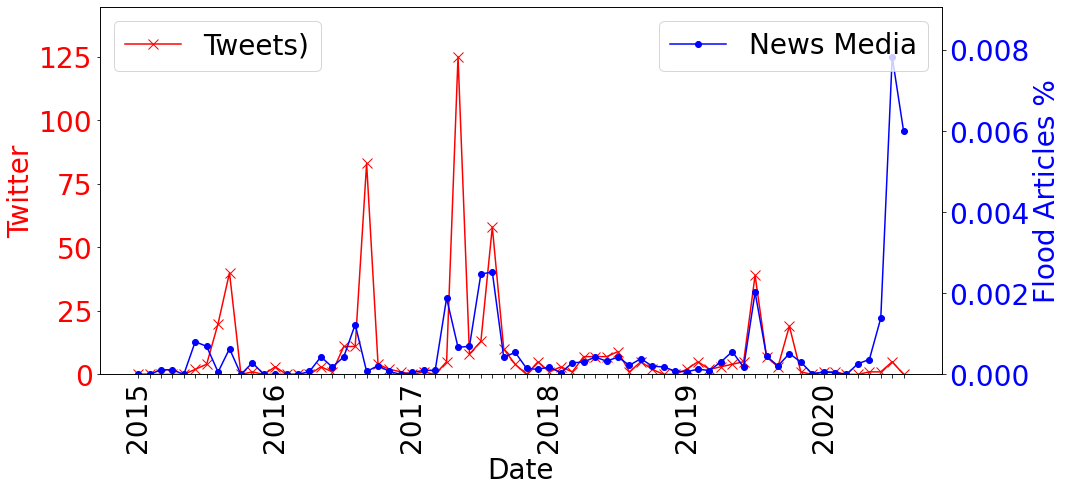

Spearmen Corr, pval: 0.6076, p-val=3.9289037771024304e-08, n=68
Pearson Corr, pval: 0.1061, p-val=0.38900606700431517, n=68


<Figure size 1080x504 with 0 Axes>

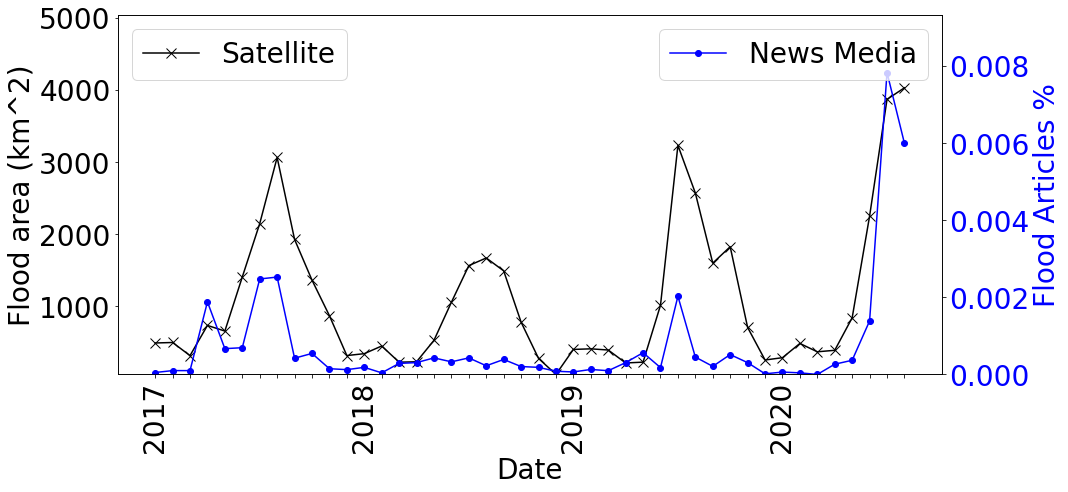

Spearmen Corr, pval: 0.6525, p-val=1.5893434413436664e-06, n=44
Pearson Corr, pval: 0.7808, p-val=4.058181166384434e-10, n=44


<Figure size 1080x504 with 0 Axes>

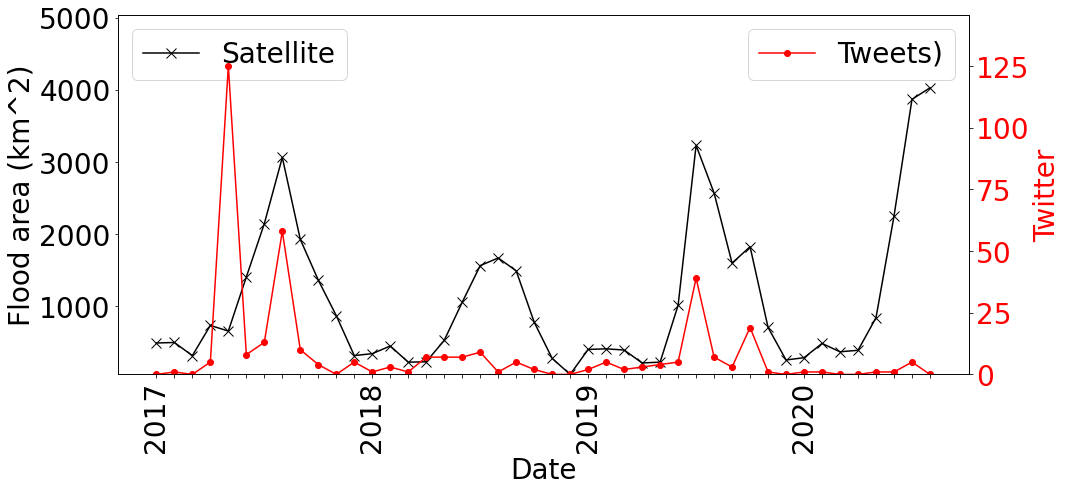

Spearmen Corr, pval: 0.4656, p-val=0.0014482215632086609, n=44
Pearson Corr, pval: 0.2011, p-val=0.19044718927403875, n=44
Division: barishal


<Figure size 1080x504 with 0 Axes>

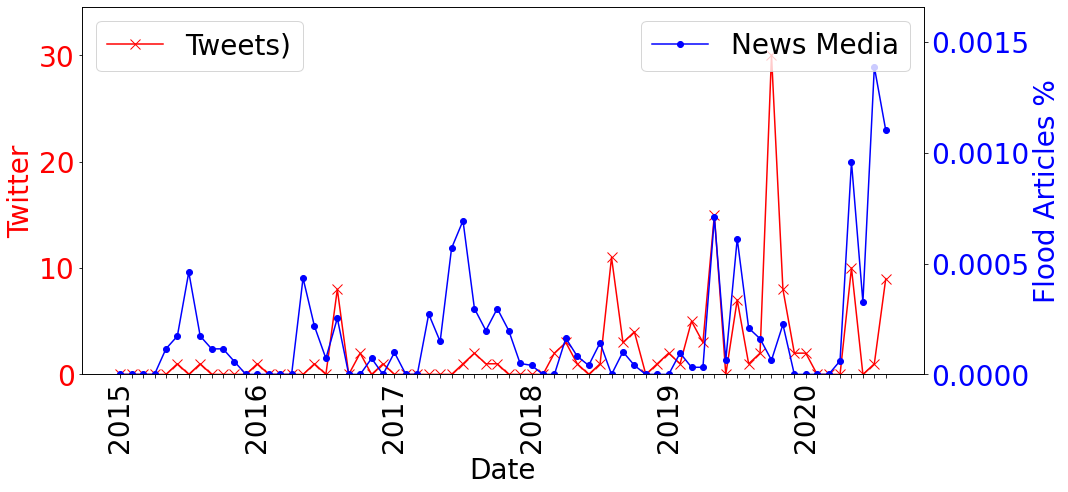

Spearmen Corr, pval: 0.2649, p-val=0.029053435984614955, n=68
Pearson Corr, pval: 0.251, p-val=0.038928455185197004, n=68


<Figure size 1080x504 with 0 Axes>

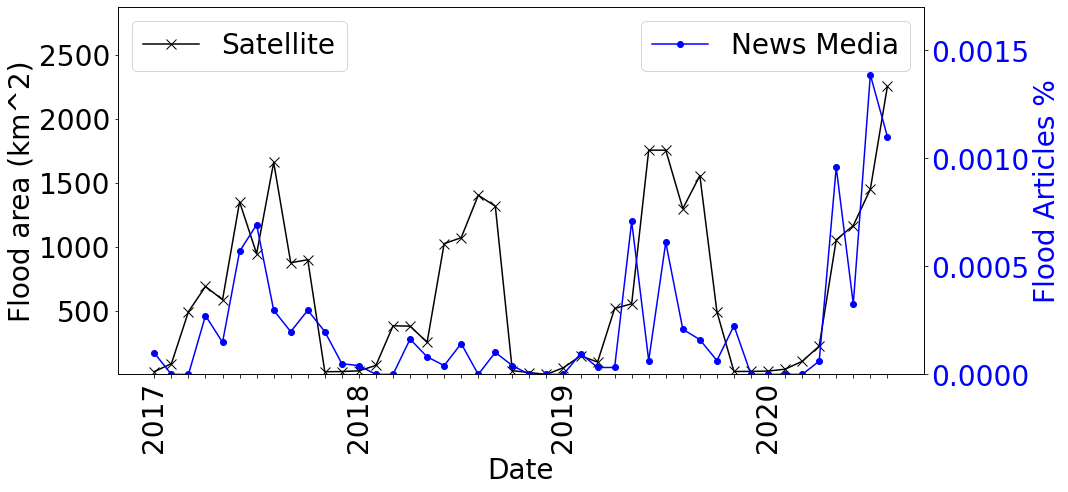

Spearmen Corr, pval: 0.5861, p-val=2.915537466870071e-05, n=44
Pearson Corr, pval: 0.5831, p-val=3.269618175012974e-05, n=44


<Figure size 1080x504 with 0 Axes>

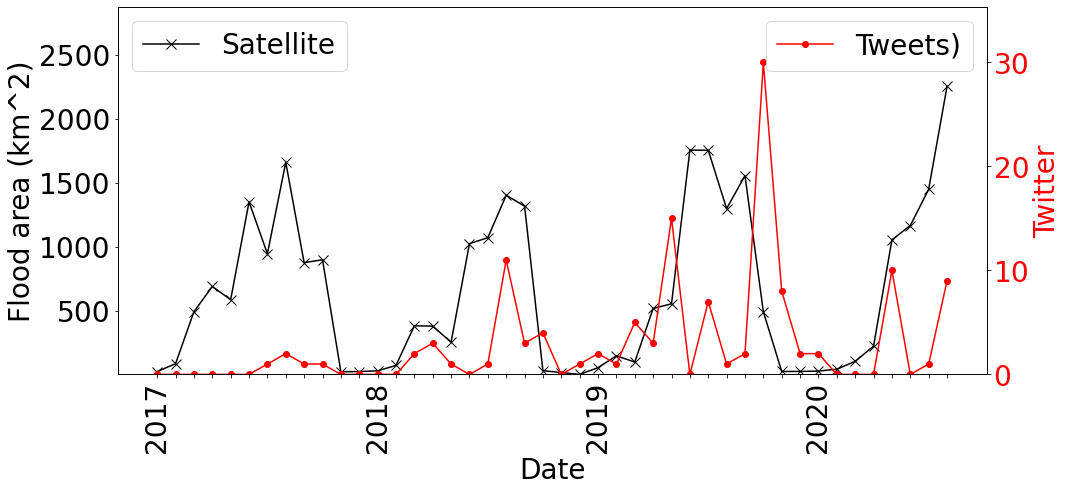

Spearmen Corr, pval: 0.2406, p-val=0.11573731701262405, n=44
Pearson Corr, pval: 0.1405, p-val=0.3630193297862663, n=44
Division: chattogram


<Figure size 1080x504 with 0 Axes>

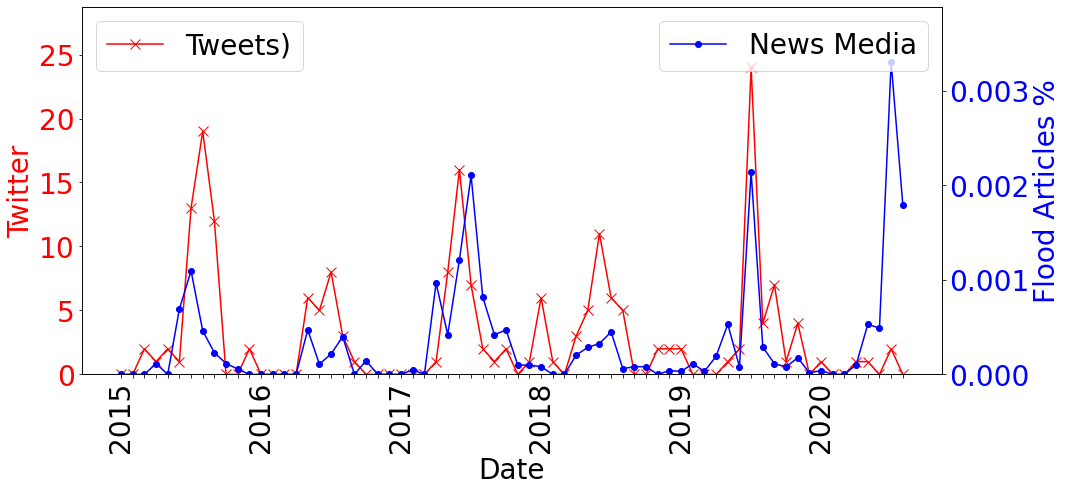

Spearmen Corr, pval: 0.5284, p-val=3.63346682443274e-06, n=68
Pearson Corr, pval: 0.4161, p-val=0.00041678906975173535, n=68


<Figure size 1080x504 with 0 Axes>

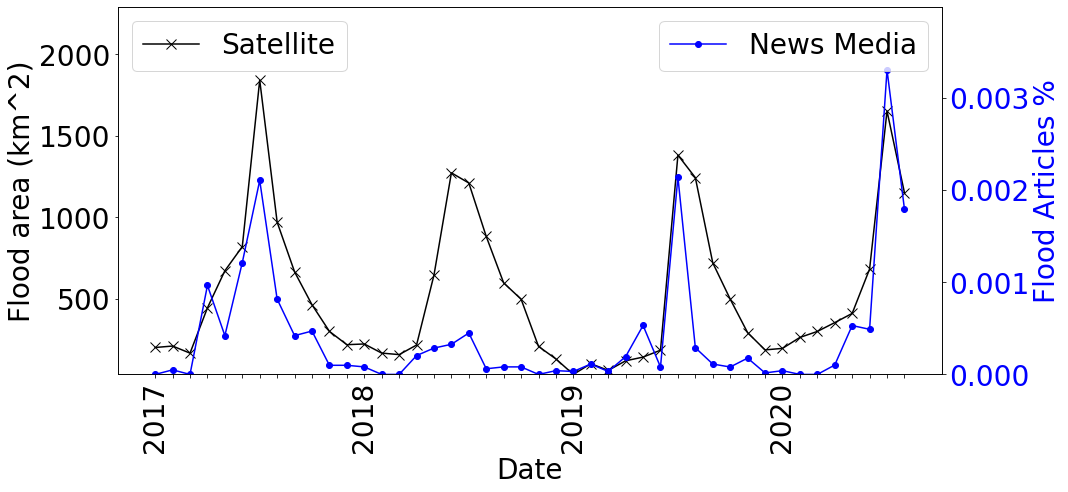

Spearmen Corr, pval: 0.6696, p-val=6.68236239121372e-07, n=44
Pearson Corr, pval: 0.7657, p-val=1.3988559901263181e-09, n=44


<Figure size 1080x504 with 0 Axes>

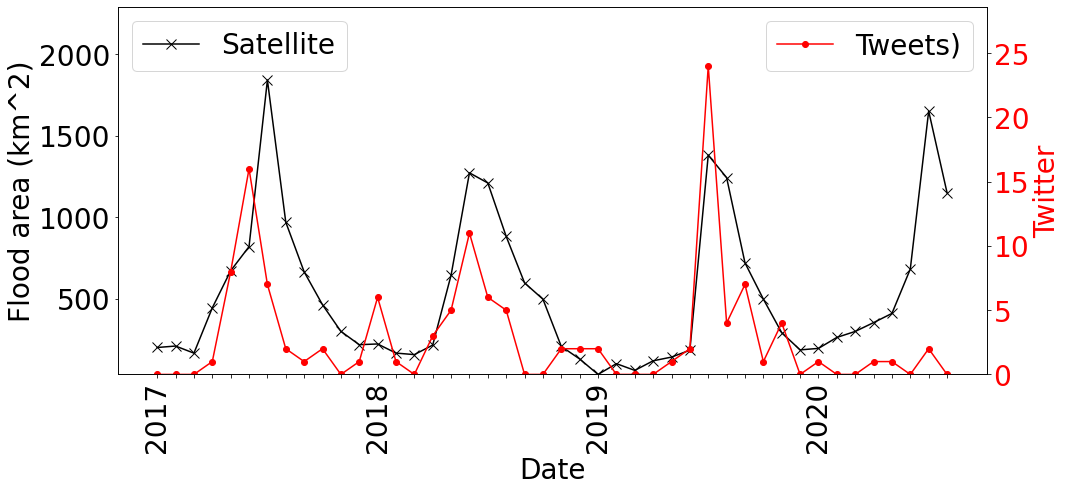

Spearmen Corr, pval: 0.5095, p-val=0.00041165822425303435, n=44
Pearson Corr, pval: 0.5377, p-val=0.00016718374606947893, n=44
Division: khulna


<Figure size 1080x504 with 0 Axes>

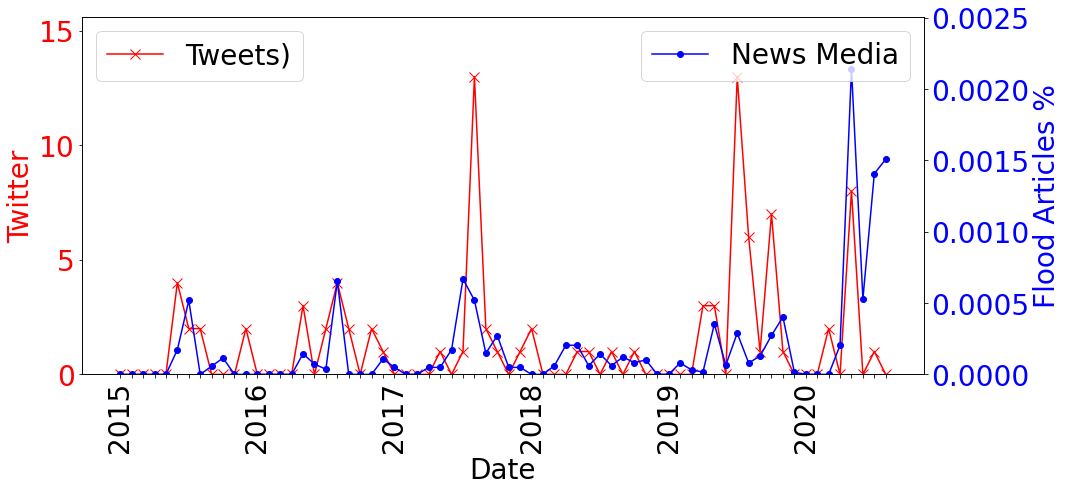

Spearmen Corr, pval: 0.3851, p-val=0.0011819670049458945, n=68
Pearson Corr, pval: 0.3462, p-val=0.003826215811860986, n=68


<Figure size 1080x504 with 0 Axes>

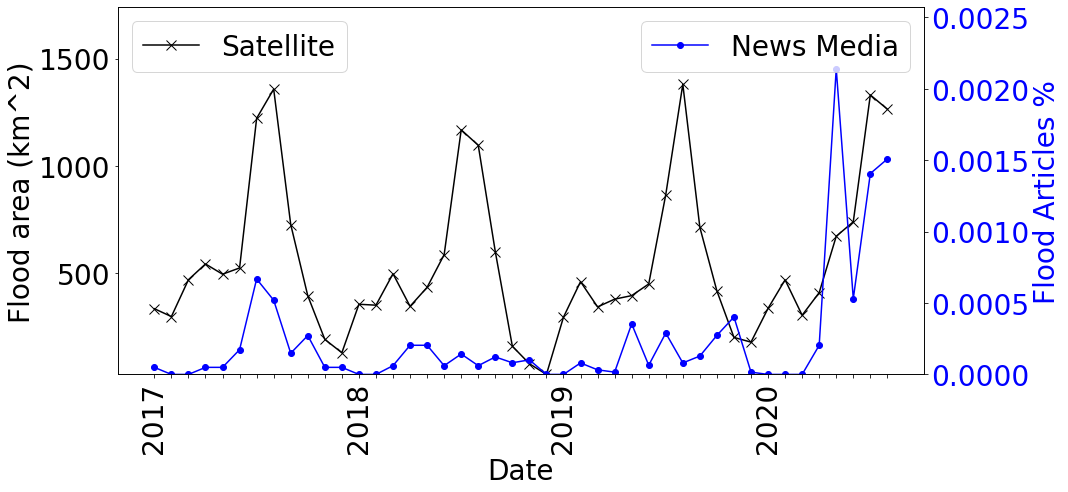

Spearmen Corr, pval: 0.5356, p-val=0.00017959716430596202, n=44
Pearson Corr, pval: 0.4825, p-val=0.0009101480380382889, n=44


<Figure size 1080x504 with 0 Axes>

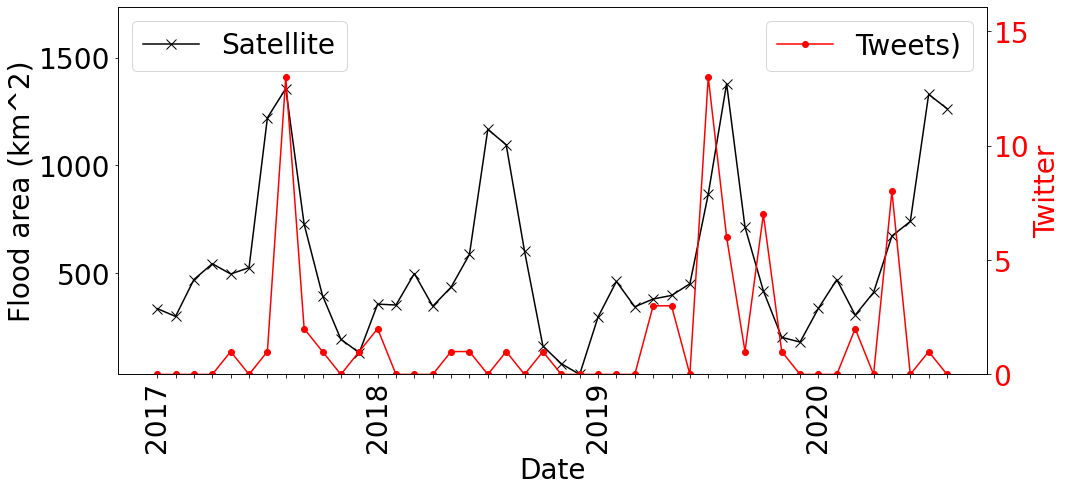

Spearmen Corr, pval: 0.2913, p-val=0.055030669349149096, n=44
Pearson Corr, pval: 0.3962, p-val=0.00776635919768557, n=44
Division: rangpur


<Figure size 1080x504 with 0 Axes>

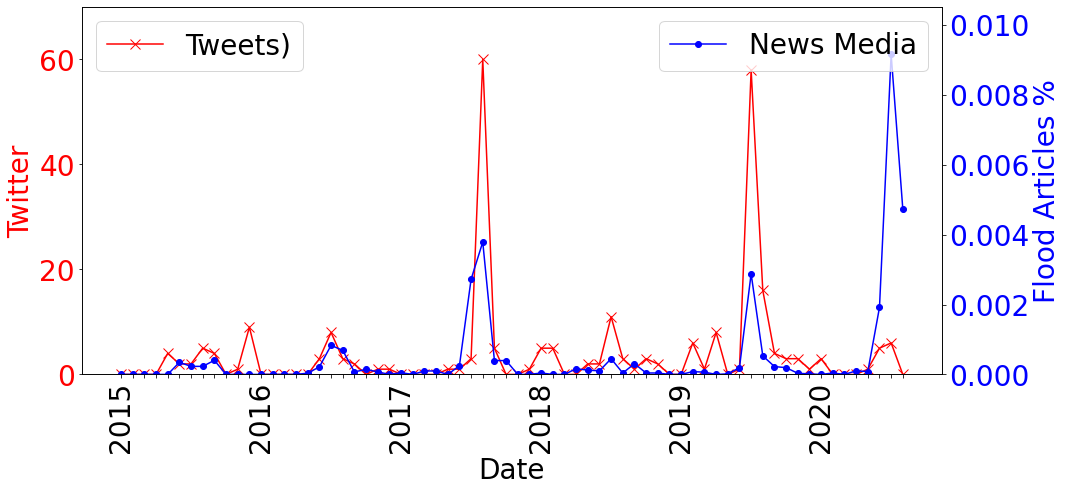

Spearmen Corr, pval: 0.4738, p-val=4.4734440346891636e-05, n=68
Pearson Corr, pval: 0.3986, p-val=0.0007611945037503755, n=68


<Figure size 1080x504 with 0 Axes>

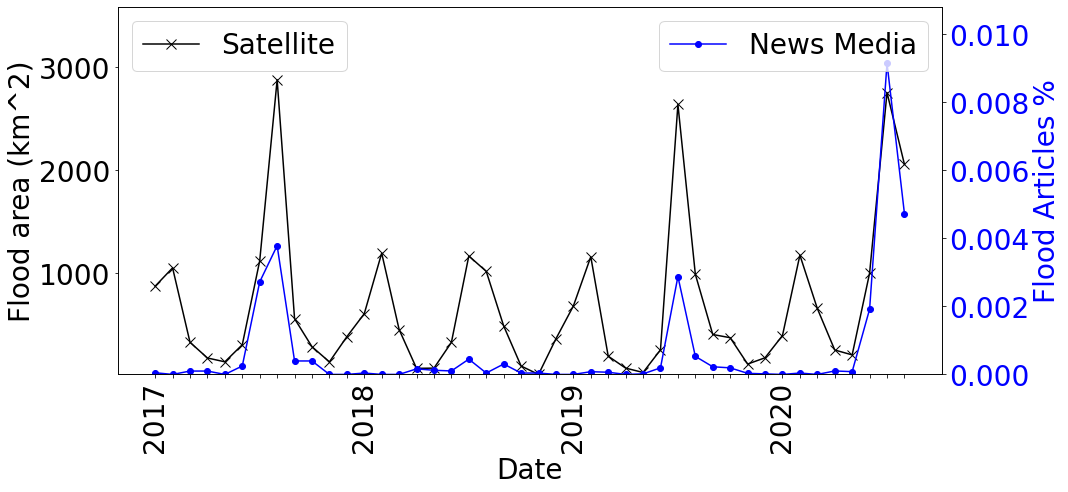

Spearmen Corr, pval: 0.3425, p-val=0.022853007653335478, n=44
Pearson Corr, pval: 0.7871, p-val=2.3566437192181055e-10, n=44


<Figure size 1080x504 with 0 Axes>

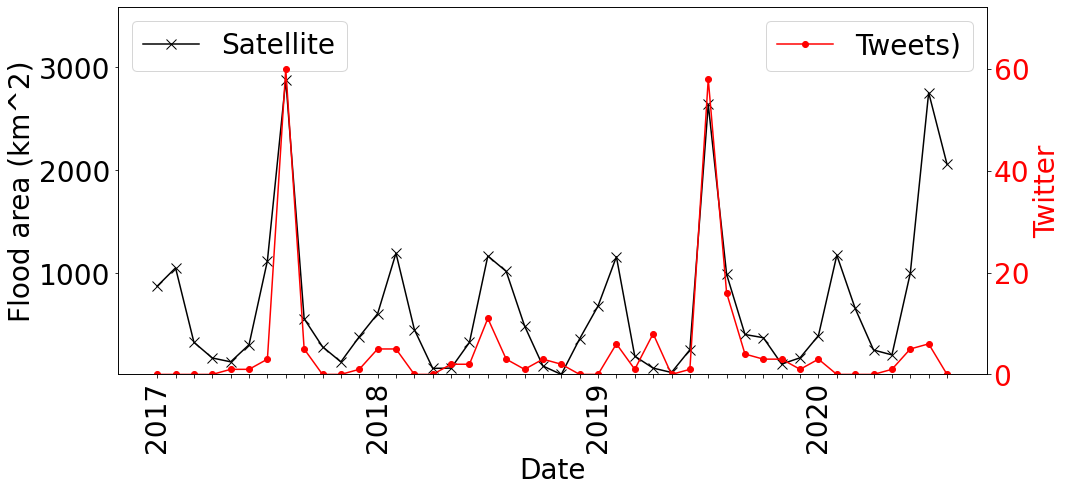

Spearmen Corr, pval: 0.3353, p-val=0.026088244442473093, n=44
Pearson Corr, pval: 0.6825, p-val=3.346417577397252e-07, n=44
Division: mymensingh


<Figure size 1080x504 with 0 Axes>

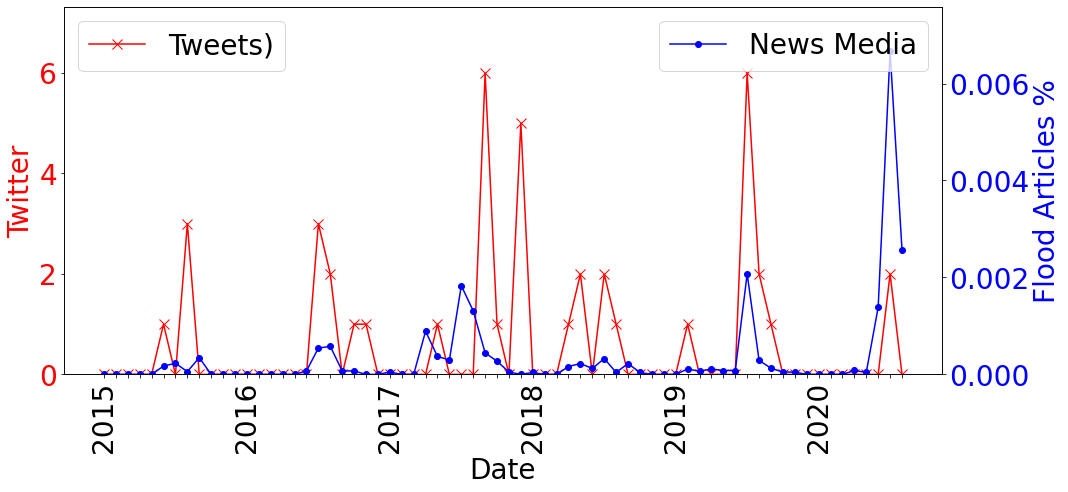

Spearmen Corr, pval: 0.4448, p-val=0.00014434659973460408, n=68
Pearson Corr, pval: 0.2485, p-val=0.04099445600502233, n=68


<Figure size 1080x504 with 0 Axes>

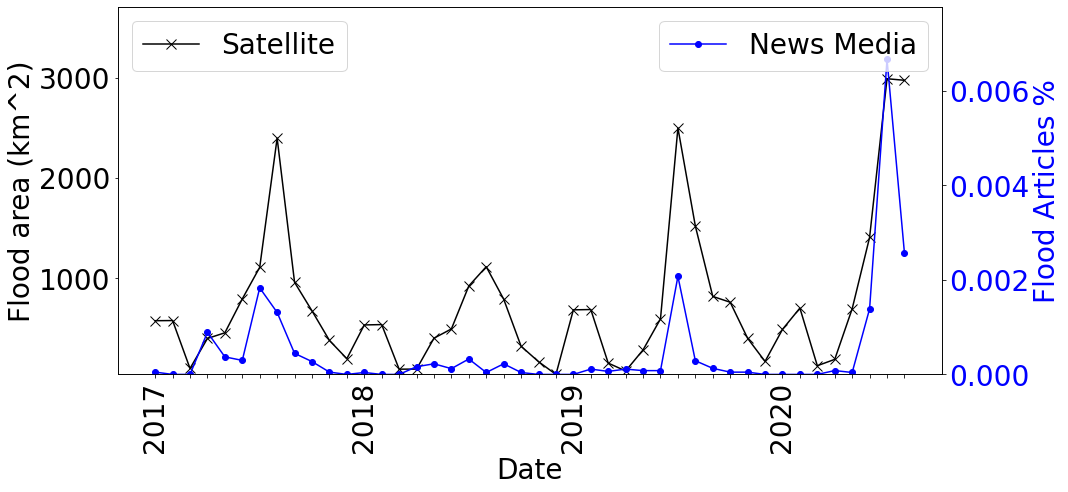

Spearmen Corr, pval: 0.5924, p-val=2.2676581201421515e-05, n=44
Pearson Corr, pval: 0.7896, p-val=1.8920297767077178e-10, n=44


<Figure size 1080x504 with 0 Axes>

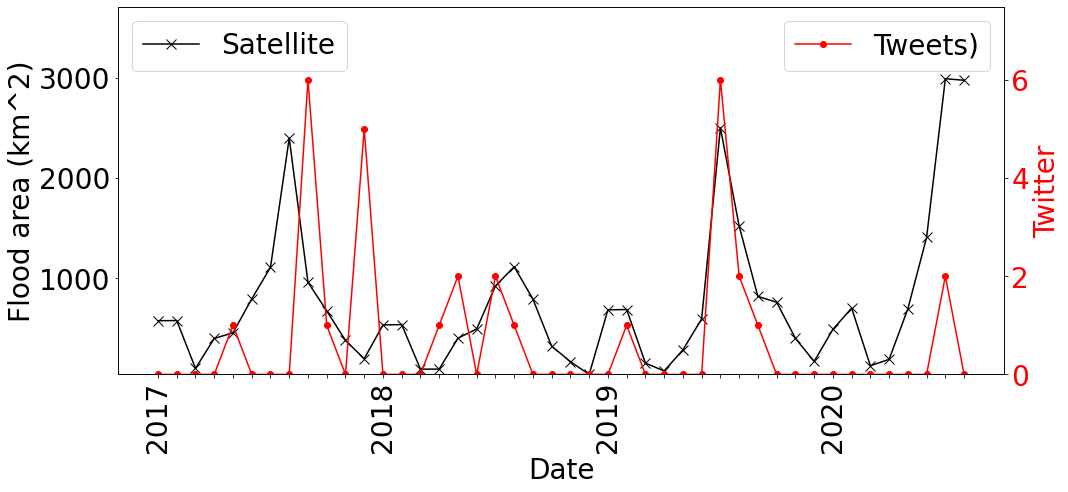

Spearmen Corr, pval: 0.3381, p-val=0.024775186384837375, n=44
Pearson Corr, pval: 0.3078, p-val=0.0421058935081293, n=44
Division: all


<Figure size 1080x504 with 0 Axes>

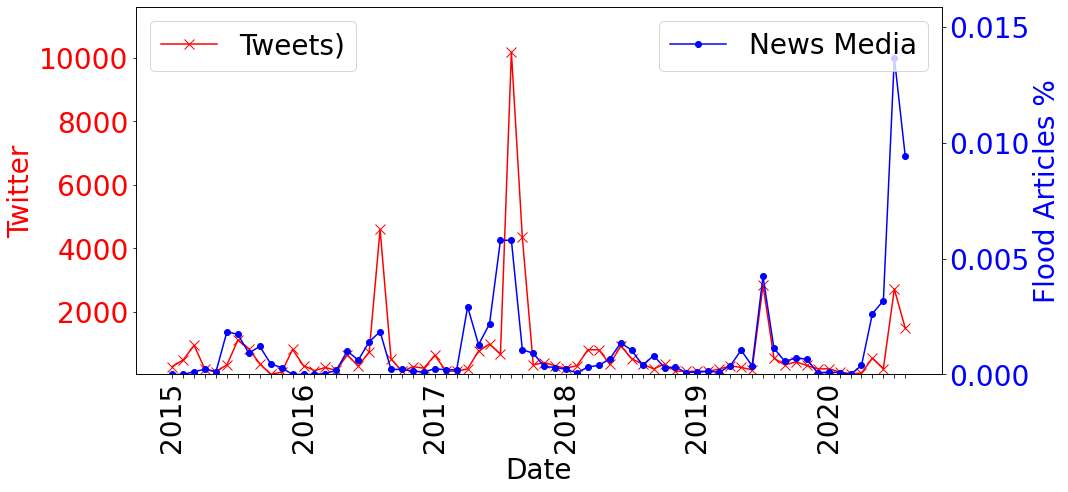

Spearmen Corr, pval: 0.5712, p-val=3.640994995919603e-07, n=68
Pearson Corr, pval: 0.4667, p-val=6.021506871714784e-05, n=68


<Figure size 1080x504 with 0 Axes>

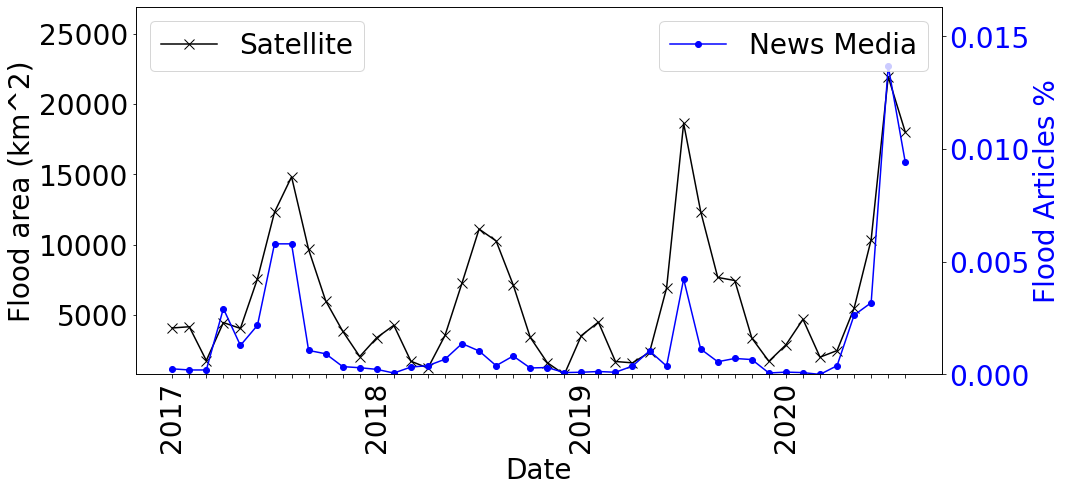

Spearmen Corr, pval: 0.696, p-val=1.5643603817293738e-07, n=44
Pearson Corr, pval: 0.8215, p-val=8.389908518171541e-12, n=44


<Figure size 1080x504 with 0 Axes>

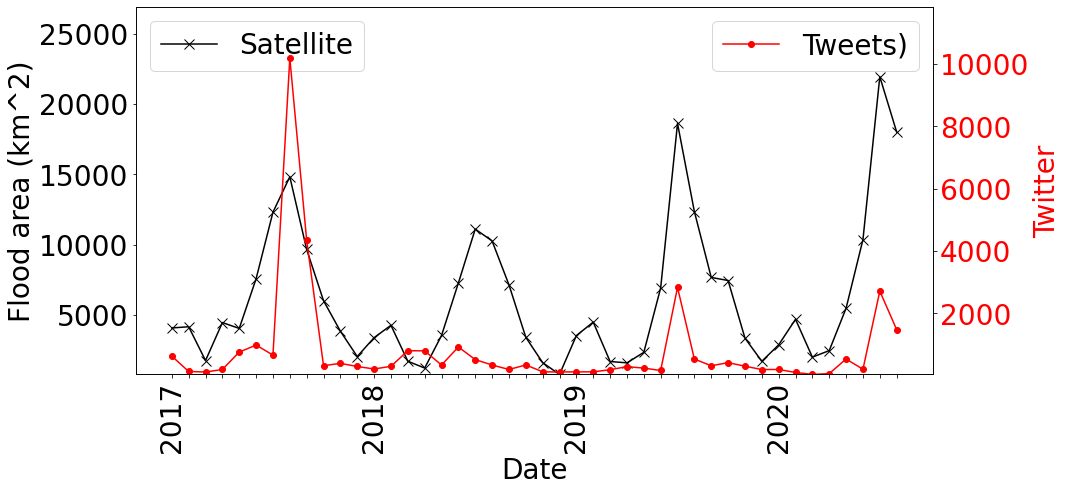

Spearmen Corr, pval: 0.5518, p-val=0.00010347838819649685, n=44
Pearson Corr, pval: 0.5297, p-val=0.00021794137155776804, n=44


In [122]:
result = {}
save_root = '/Users/tejitpabari/Desktop/BangladeshFloodResearch/nlp_flood_research/classifier/images/cross_corr'
plot=True
tsn('sylhet', plot=plot, save_root=save_root)
tsn('rajshahi', plot=plot, save_root=save_root)
tsn('dhaka', plot=plot, save_root=save_root)
tsn('barishal', plot=plot, save_root=save_root)
tsn('chattogram', plot=plot, save_root=save_root)
tsn('khulna', plot=plot, save_root=save_root)
tsn('rangpur', plot=plot, save_root=save_root)
tsn('mymensingh', plot=plot, save_root=save_root)
tsn('all', plot=plot, save_root=save_root)

In [127]:
pd.options.display.max_colwidth = 200
org_result = result.copy()
result2 = {k:
           {k2:', '.join(['{}'.format(v3[0]) 
                          for k3,v3 in v2.items()]) 
              for k2,v2 in v.items()} 
           for k,v in result.items()}
result3 = {k:
           {k2:'{}, {:.10f}'.format(v2['spearmen'][0], v2['spearmen'][1]) 
              for k2,v2 in v.items()}
           for k,v in result.items()}
result4 = {k:
           {k2:'{}, {:.8f}'.format(v2['pearson'][0], v2['pearson'][1]) 
              for k2,v2 in v.items()} 
           for k,v in result.items()}
pd.DataFrame(result3)

\begin{tabular}{llllllllll}
\toprule
{} &              Sylhet &            Rajshahi &               Dhaka &            Barishal &          Chattogram &              Khulna &             Rangpur &          Mymensingh &                 All \\
\midrule
news-twitter     &  0.5005, 0.00001384 &  0.2478, 0.04163460 &  0.1061, 0.38900607 &   0.251, 0.03892846 &  0.4161, 0.00041679 &  0.3462, 0.00382622 &  0.3986, 0.00076119 &  0.2485, 0.04099446 &  0.4667, 0.00006022 \\
news-sentinel    &  0.6913, 0.00000020 &  0.7083, 0.00000008 &  0.7808, 0.00000000 &  0.5831, 0.00003270 &  0.7657, 0.00000000 &  0.4825, 0.00091015 &  0.7871, 0.00000000 &  0.7896, 0.00000000 &  0.8215, 0.00000000 \\
twitter-sentinel &  0.5995, 0.00001707 &  0.4753, 0.00111328 &  0.2011, 0.19044719 &  0.1405, 0.36301933 &  0.5377, 0.00016718 &  0.3962, 0.00776636 &  0.6825, 0.00000033 &  0.3078, 0.04210589 &  0.5297, 0.00021794 \\
\bottomrule
\end{tabular}



## Newspapers, monthly, norm=yearly

In [110]:
newspaperDataFiles = {'bdnews':'timeseries_data/yearPublished_day_newspaper/bdnews.json',
                 'dailyObserver': 'timeseries_data/yearPublished_day_newspaper/dailyObserver.json',
                 'dailySun':'timeseries_data/yearPublished_day_newspaper/dailySun.json',
                 'dhakaTribune':'timeseries_data/yearPublished_day_newspaper/dhakaTribune.json',
                 'newAge':'timeseries_data/yearPublished_day_newspaper/newAge.json',
                 'theIndependent':'timeseries_data/yearPublished_day_newspaper/theIndependent.json',
                 'theDailyStar':'timeseries_data/yearPublished_day_newspaper/theDailyStar.json',
                 'prothomalo': 'timeseries_data/yearPublished_day_newspaper/prothomalo.json'
                }
newspaperIgnoreYears = { 'dailyObserver': [2019,2020]
                }

In [36]:
def plot_newspaper_normalized(newspaper):
    nData = json.load(open(newspaperDataFiles[newspaper]))
    nNormData = paperCounts[newspaper]
    ignoreDates = {2020:[8,9,10,11,12]}
    aggDayPrev = complete_day([(k,v) for k,v in nData.items()], year_range=[2017,2020], 
                          aggType='month', ignoreDates=ignoreDates)
    aggDay = complete_day([(k,v) for k,v in nData.items()], year_range=[2017,2020], 
                          aggType='month', normDict=nNormData, normAgg='year', ignoreDates=ignoreDates)
    plt_args = {
        'xticksFontSize': 20,
        'yticksFontSize': 20,
        'xlabelFontSize': 22,
        'ylabelFontSize': 22,
        'legendFontSize': 22,
    }
    plot_2timeseries(
                {'count_list': aggDayPrev, 'label':'flood articles', 
                 'color':'r', 'ylabel':'# articles'},
                {'count_list': aggDay, 'label':'Normed flood articles', 
                 'color': 'b', 'ylabel': '# articles / total'},
                '{} - Flood articles (aggregated monthly) and Normed Flood articles (yearly) vs Date'.format(newspaper),
                'Date', True, skip=2, plt_args=plt_args)

<Figure size 1080x504 with 0 Axes>

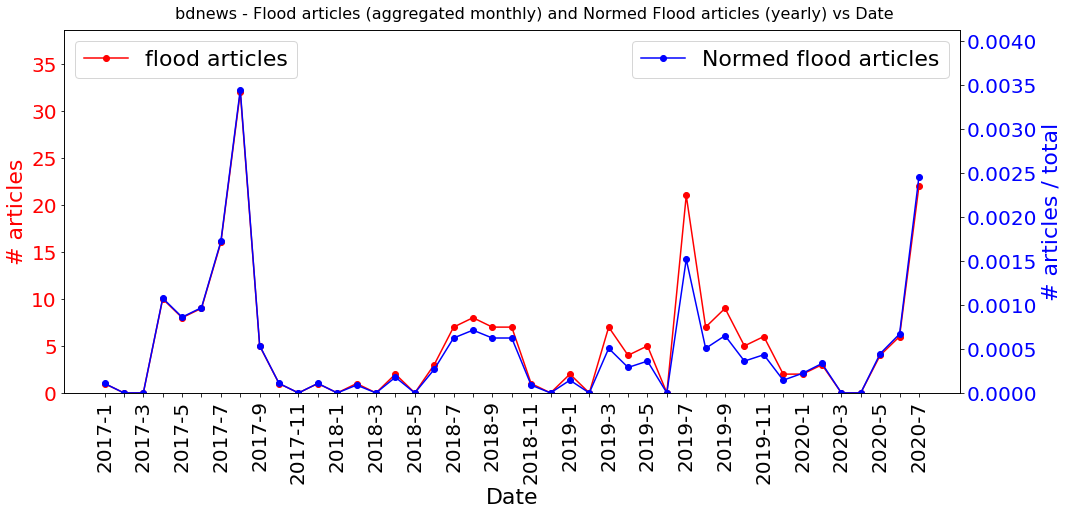

<Figure size 1080x504 with 0 Axes>

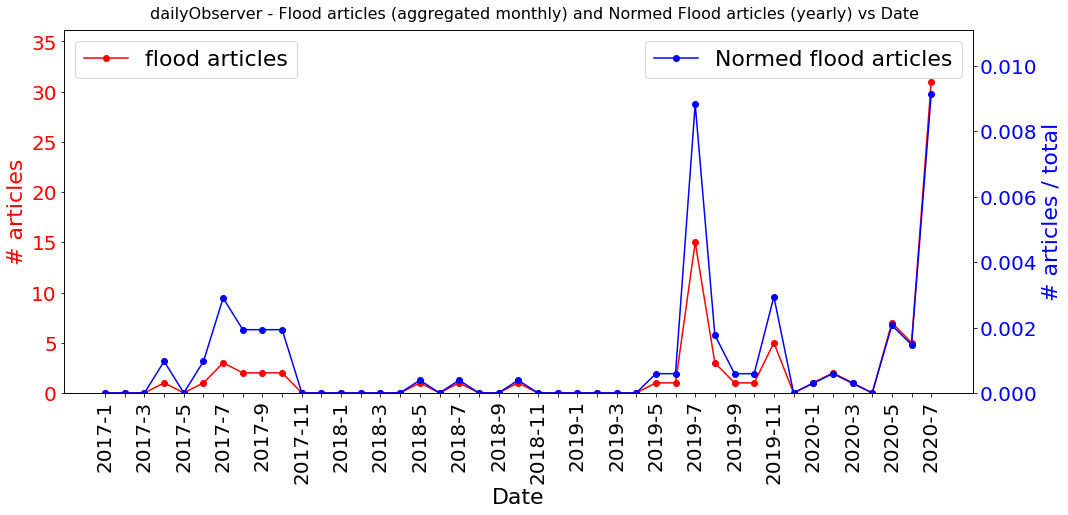

<Figure size 1080x504 with 0 Axes>

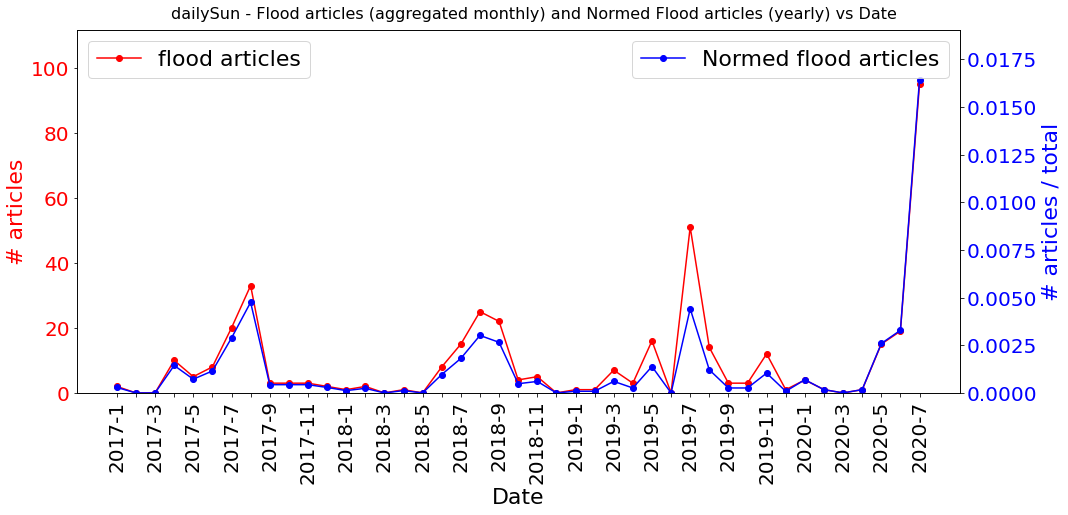

<Figure size 1080x504 with 0 Axes>

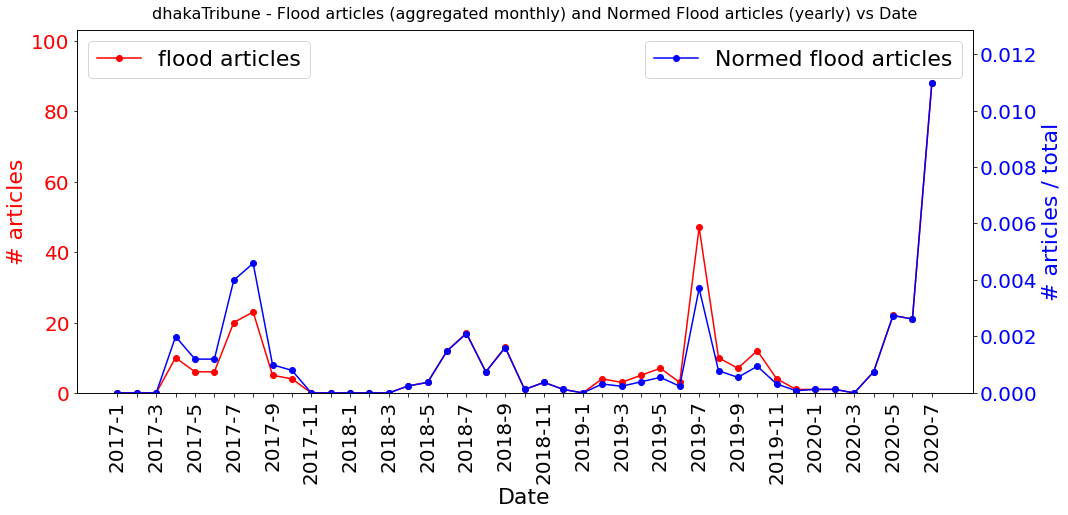

<Figure size 1080x504 with 0 Axes>

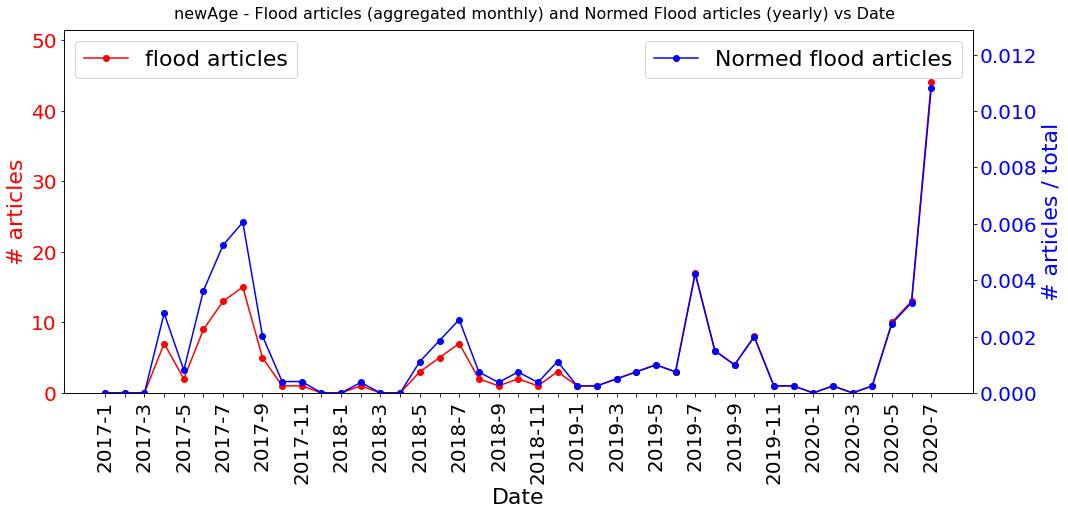

<Figure size 1080x504 with 0 Axes>

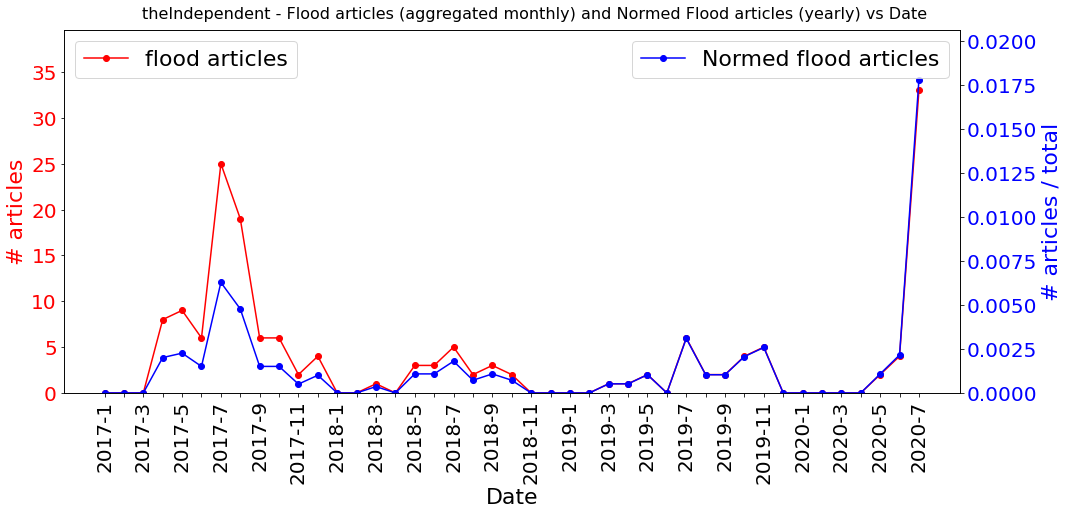

<Figure size 1080x504 with 0 Axes>

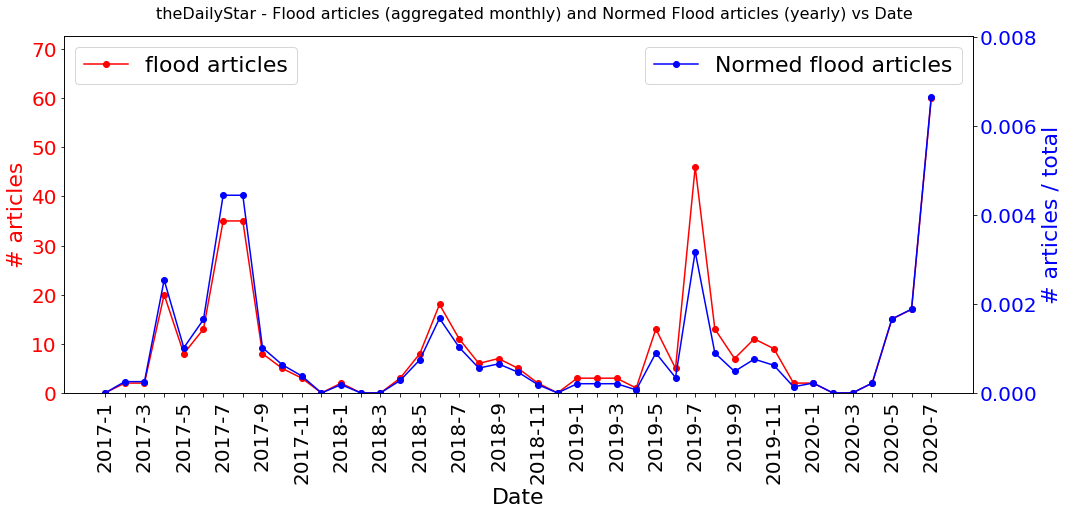

<Figure size 1080x504 with 0 Axes>

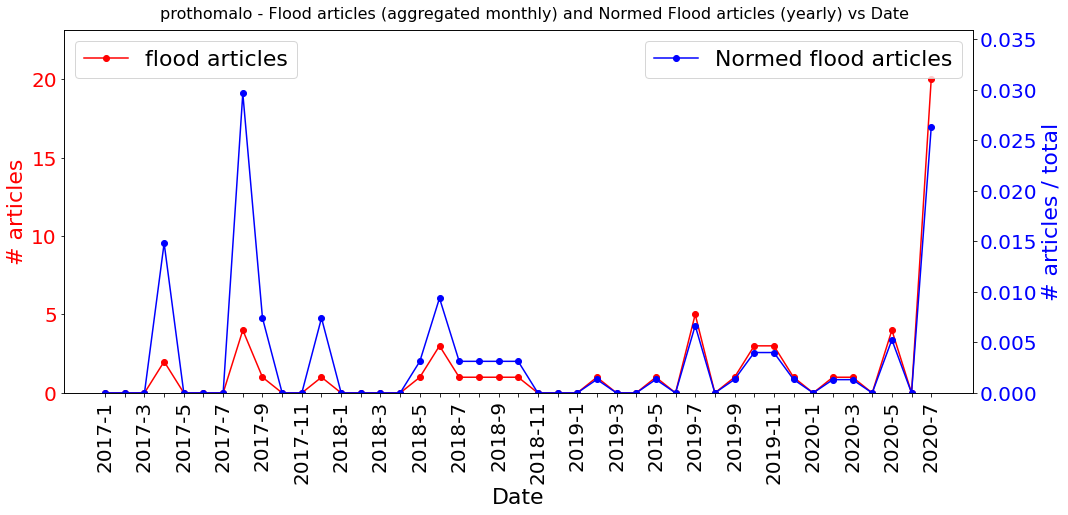

In [37]:
for newspaper in newspaperDataFiles:
    try:
        plot_newspaper_normalized(newspaper)
    except Exception as e:
        print(e)
        continue